In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from neuron_utils import NeuronUtils
from abstract_neuron import AbstractNeuron
from plastic_neuron import PlasticNeuron

# Poisson inputs at theta frequency with and without electric field (TI): combining the results from multiple runs

In [4]:
idxs = np.arange(0, 10)
idxs = np.delete(idxs, 3)

file_labels = {
    "No TI": "no_ti/0",
    "5 Hz": "1000/90_90_5/50",
    "130 Hz": "1000/90_90_130"
}

output_dir = "output/temporal-interference/poisson_delay_theta"
output_dir_130 = "output/temporal-interference/poisson_theta"
output_dir_no_ti = "output/temporal-interference/poisson_theta"

colors = {
    "No TI": "steelblue",
    "5 Hz": "lightcoral",
    "130 Hz": "mediumseagreen"
}

## Distribution of firing frequency

In [5]:
spiking_frequencies = {
    "No TI": [pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/spike_frequency.csv").Frequency.values for idx in idxs],
    "5 Hz": [pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/spike_frequency.csv").Frequency.values for idx in idxs],
    "130 Hz": [pd.read_csv(f"{output_dir_130}/{idx}/{file_labels['130 Hz']}/spike_frequency.csv").Frequency.values for idx in idxs]
}

spiking_frequencies["No TI"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["No TI"])))
spiking_frequencies["5 Hz"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["5 Hz"])))
spiking_frequencies["130 Hz"] = np.array(list(itertools.chain.from_iterable(spiking_frequencies["130 Hz"])))

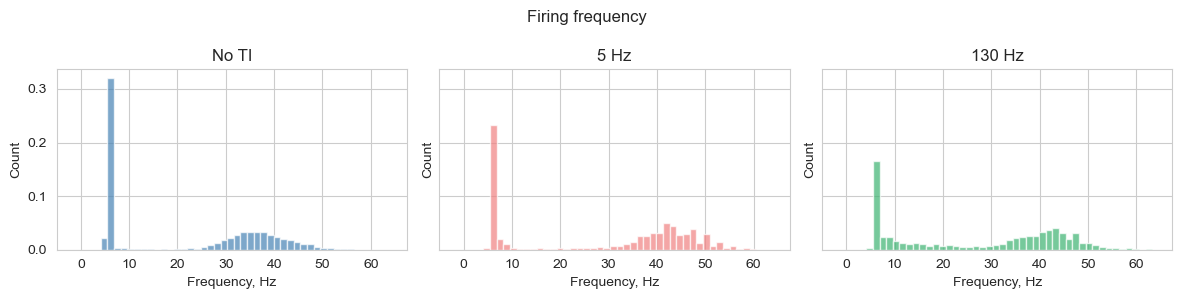

In [6]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

max = np.max([spiking_frequencies[key].max() for key in spiking_frequencies.keys()])
min = 0

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    spike_frequency = spiking_frequencies[label]
    axs[i].hist(spike_frequency, bins = bin_edges, alpha = 0.7, color = colors[label], density = True)

    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, max)
    axs[i].set_title(label)

fig.suptitle("Firing frequency")
fig.tight_layout()
plt.show()

## Distribution of interspike intervals

In [7]:
def calculate_isi(spike_frequency):
    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])

    return np.diff(spike_times)

In [8]:
interspike_intervals = {
    "No TI": [ calculate_isi(pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/spike_frequency.csv")) for idx in idxs ],
    "5 Hz": [ calculate_isi(pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/spike_frequency.csv")) for idx in idxs ],
    "130 Hz": [ calculate_isi(pd.read_csv(f"{output_dir_130}/{idx}/{file_labels['130 Hz']}/spike_frequency.csv")) for idx in idxs ]
}

interspike_intervals["No TI"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["No TI"])))
interspike_intervals["5 Hz"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["5 Hz"])))
interspike_intervals["130 Hz"] = np.array(list(itertools.chain.from_iterable(interspike_intervals["130 Hz"])))

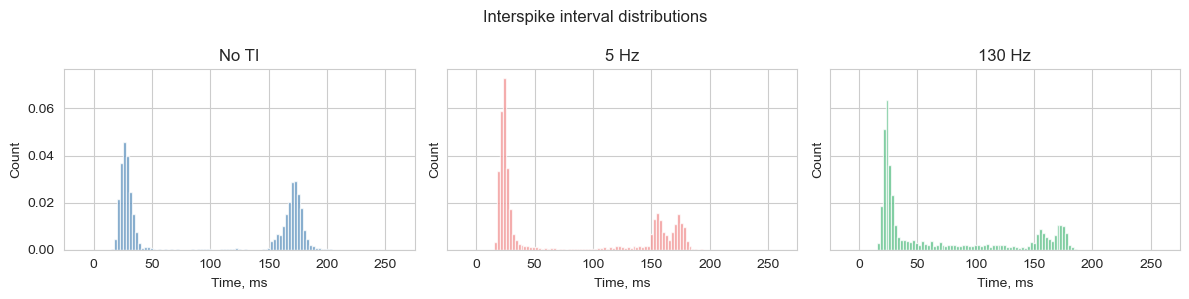

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey = True)

min = 0
max = 250

bin_edges = np.linspace(min, max, num = 100)

for i, label in enumerate(file_labels.keys()):
    isi = interspike_intervals[label]

    axs[i].hist(isi, bins = bin_edges, density = True, alpha = 0.75, label = label, color = colors[label])

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Count")
    axs[i].set_title(label)
    axs[i].set_xlim(min - max * 0.1, max * 1.1)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

In [10]:
final_synaptic_weights = {
    "No TI": [ pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ],
    "5 Hz": [ pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ],
    "130 Hz": [ pd.read_csv(f"{output_dir_130}/{idx}/{file_labels['130 Hz']}/synapse_weights.csv").iloc[-1][2:] for idx in idxs ]
}

final_synaptic_weights["No TI"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["No TI"])))
final_synaptic_weights["5 Hz"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["5 Hz"])))
final_synaptic_weights["130 Hz"] = np.array(list(itertools.chain.from_iterable(final_synaptic_weights["130 Hz"])))

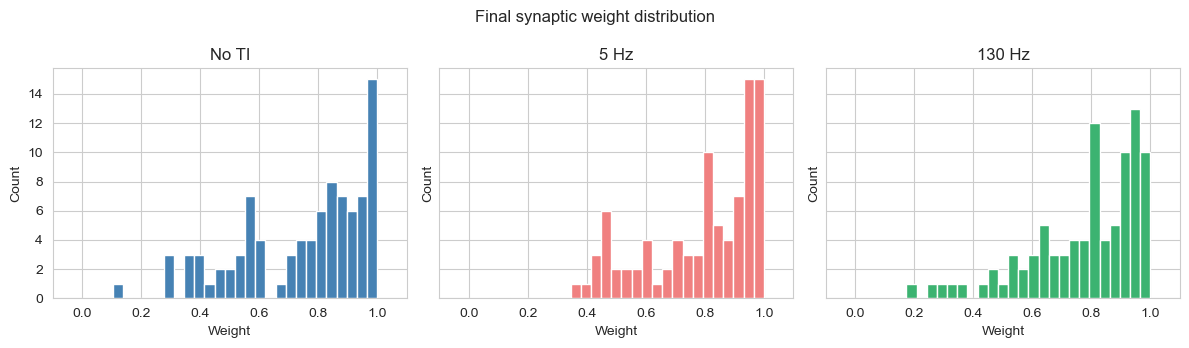

In [11]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(0, 1, num = 30)

for i, label in enumerate(file_labels.keys()):
    synapse_weights = final_synaptic_weights[label]

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(synapse_weights, color = colors[label], zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Final synaptic weight distribution")
fig.tight_layout()
plt.show()

In [12]:
original_synaptic_weights = {
    "No TI": [ pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_weights.csv").iloc[0][2:] for idx in idxs ],
    "5 Hz": [ pd.read_csv(f"{output_dir}/{idx}/{file_labels['5 Hz']}/synapse_weights.csv").iloc[0][2:] for idx in idxs ],
    "130 Hz": [ pd.read_csv(f"{output_dir_130}/{idx}/{file_labels['130 Hz']}/synapse_weights.csv").iloc[0][2:] for idx in idxs ]
}

original_synaptic_weights["No TI"] = np.array(list(itertools.chain.from_iterable(original_synaptic_weights["No TI"])))
original_synaptic_weights["5 Hz"] = np.array(list(itertools.chain.from_iterable(original_synaptic_weights["5 Hz"])))
original_synaptic_weights["130 Hz"] = np.array(list(itertools.chain.from_iterable(original_synaptic_weights["130 Hz"])))

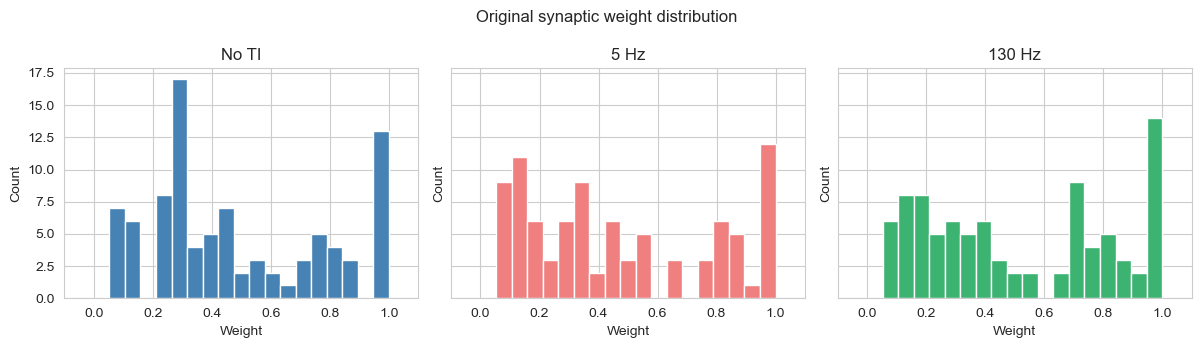

In [13]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(0, 1, num = 20)

for i, label in enumerate(file_labels.keys()):
    synapse_weights = original_synaptic_weights[label]

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(synapse_weights, color = colors[label], zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Original synaptic weight distribution")
fig.tight_layout()
plt.show()

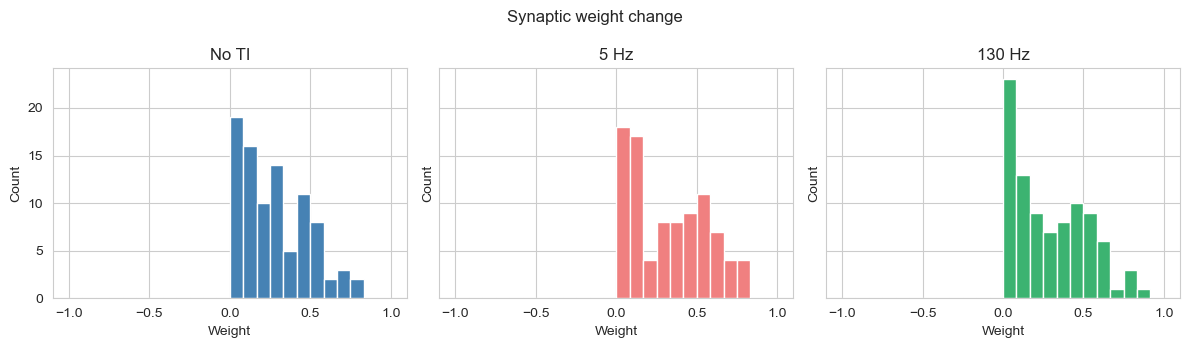

In [14]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3.5), sharey = True)

bin_edges = np.linspace(-1, 1, num = 25)

for i, label in enumerate(file_labels.keys()):
    synapse_weights = np.abs(original_synaptic_weights[label] - final_synaptic_weights[label])

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(synapse_weights, color = colors[label], zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    # axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Synaptic weight change")
fig.tight_layout()
plt.show()

Idea: the distribution of the synaptic weights might be the same but different synapses are affected differently under the same conditions. That is, the correlation between final / initial weights or the difference between them is different between the conditions.

In [15]:
import statsmodels.formula.api as smf

In [16]:
def plot_correlation_line(x, y, ax, locations = None):
    slope, intercept = np.polyfit(x, y, 1)
    corr = np.corrcoef(x, y)[0, 1]
    x_vals = np.arange(-0.1, 1.4, 0.1)
    y_vals = slope * x_vals + intercept
    
    if locations is not None:
        df_1 = pd.DataFrame({
            "Weight": x,
            "Condition": np.repeat(["X"], len(x)),
            "Location": locations
        })
        
        df_2 = pd.DataFrame({
            "Weight": y,
            "Condition": np.repeat(["Y"], len(y)),
            "Location": locations
        })
        
        df = pd.concat([df_1, df_2])
        
        model = smf.ols('Weight ~ Location * C(Condition)', data=df).fit()
        print(model.summary())
    
    ax.plot(
        x_vals,
        y_vals,
        color = "gray",
        label = f"R = {round(corr, 2)}"
    )

In [17]:
neuron = PlasticNeuron(
    n_synapses = 0
)

NeuronUtils.set_field(
    psi_deg = 90,
    phi_deg = 90
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 0 synapses


In [18]:
dendrites = np.array(list(itertools.chain.from_iterable(
    [ pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_info.csv").Dendrite.values for idx in idxs ]
)))

distances = np.array(list(itertools.chain.from_iterable(
    [ pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_info.csv").Distance.values for idx in idxs ]
)))

angles = np.array(list(itertools.chain.from_iterable(
    [
        NeuronUtils.calculate_synapse_angles(
            pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_info.csv")
        ) for idx in idxs
    ]
)))

locations = np.array(list(itertools.chain.from_iterable(
    [ pd.read_csv(f"{output_dir_no_ti}/{idx}/{file_labels['No TI']}/synapse_info.csv").Location.values for idx in idxs ]
)))

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     18.21
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           2.45e-10
Time:                        14:31:12   Log-Likelihood:                 57.319
No. Observations:                 180   AIC:                            -106.6
Df Residuals:                     176   BIC:                            -93.87
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

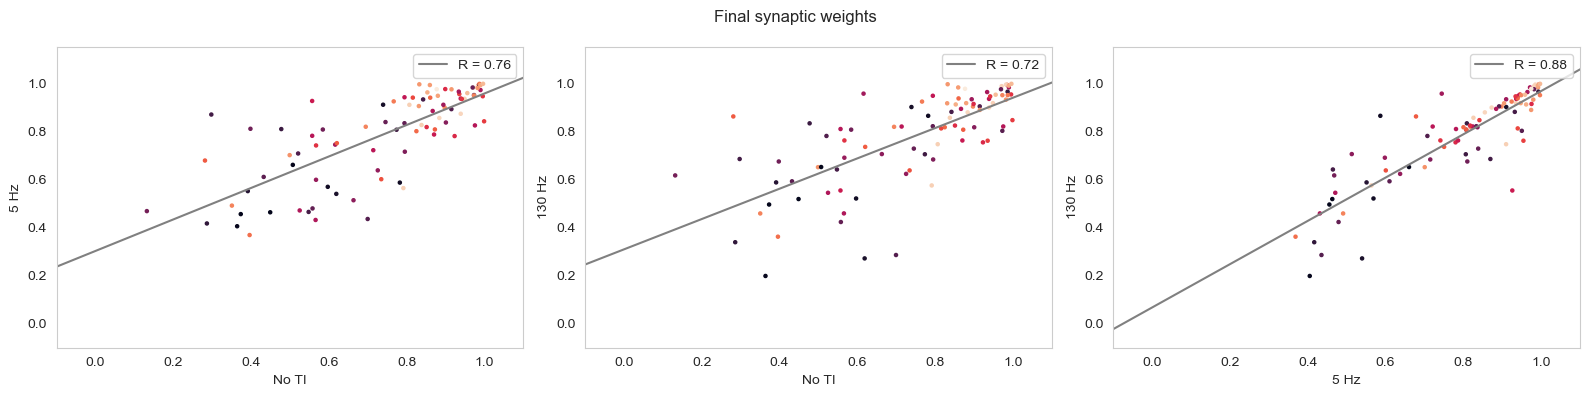

In [19]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (16, 4))

x = final_synaptic_weights["No TI"]
y = final_synaptic_weights["5 Hz"]

axs[0].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[0], locations = locations)

axs[0].set_xlabel("No TI")
axs[0].set_ylabel("5 Hz")
axs[0].set_xlim(-0.1, 1.1)
axs[0].set_ylim(-0.1, 1.15)
axs[0].legend(loc = "upper right")
axs[0].grid()

x = final_synaptic_weights["No TI"]
y = final_synaptic_weights["130 Hz"]

axs[1].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[1], locations = locations)

axs[1].set_xlabel("No TI")
axs[1].set_ylabel("130 Hz")
axs[1].set_xlim(-0.1, 1.1)
axs[1].set_ylim(-0.1, 1.15)
axs[1].legend(loc = "upper right")
axs[1].grid()

x = final_synaptic_weights["5 Hz"]
y = final_synaptic_weights["130 Hz"]

axs[2].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[2], locations = locations)

axs[2].set_xlabel("5 Hz")
axs[2].set_ylabel("130 Hz")
axs[2].set_xlim(-0.1, 1.1)
axs[2].set_ylim(-0.1, 1.15)
axs[2].legend(loc = "upper right")
axs[2].grid()

fig.suptitle("Final synaptic weights")
fig.tight_layout()

plt.show()

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     11.19
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           9.35e-07
Time:                        14:31:18   Log-Likelihood:                -25.921
No. Observations:                 180   AIC:                             59.84
Df Residuals:                     176   BIC:                             72.61
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

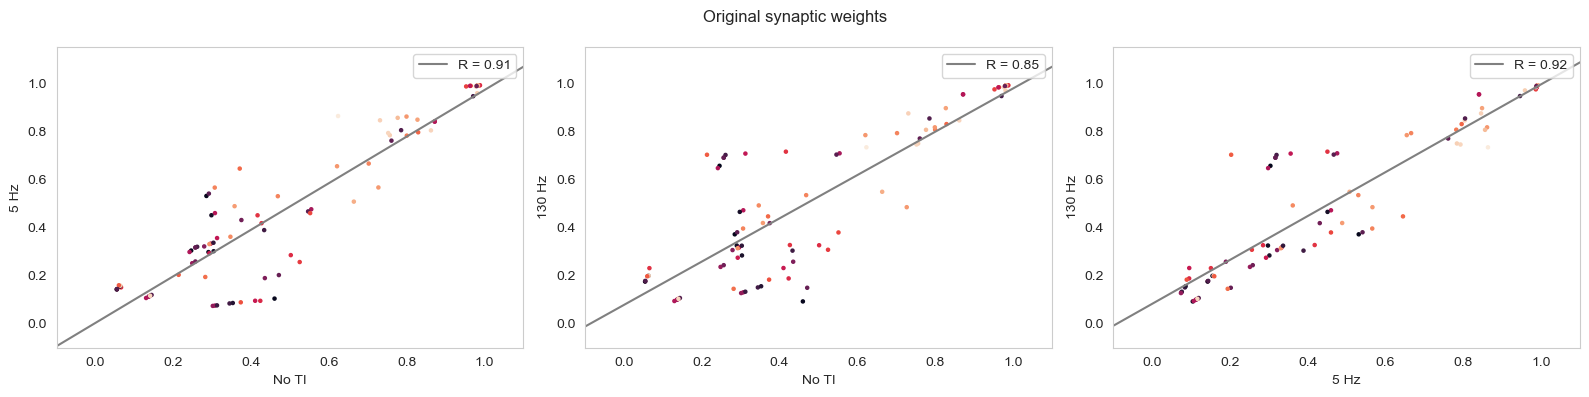

In [20]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (16, 4))

x = original_synaptic_weights["No TI"]
y = original_synaptic_weights["5 Hz"]

axs[0].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[0], locations = locations)

axs[0].set_xlabel("No TI")
axs[0].set_ylabel("5 Hz")
axs[0].set_xlim(-0.1, 1.1)
axs[0].set_ylim(-0.1, 1.15)
axs[0].legend(loc = "upper right")
axs[0].grid()

x = original_synaptic_weights["No TI"]
y = original_synaptic_weights["130 Hz"]

axs[1].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[1], locations = locations)

axs[1].set_xlabel("No TI")
axs[1].set_ylabel("130 Hz")
axs[1].set_xlim(-0.1, 1.1)
axs[1].set_ylim(-0.1, 1.15)
axs[1].legend(loc = "upper right")
axs[1].grid()

x = original_synaptic_weights["5 Hz"]
y = original_synaptic_weights["130 Hz"]

axs[2].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[2], locations = locations)

axs[2].set_xlabel("5 Hz")
axs[2].set_ylabel("130 Hz")
axs[2].set_xlim(-0.1, 1.1)
axs[2].set_ylim(-0.1, 1.15)
axs[2].legend(loc = "upper right")
axs[2].grid()

fig.suptitle("Original synaptic weights")
fig.tight_layout()

plt.show()

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.847
Date:                Wed, 09 Apr 2025   Prob (F-statistic):              0.140
Time:                        14:31:21   Log-Likelihood:                 4.8744
No. Observations:                 180   AIC:                            -1.749
Df Residuals:                     176   BIC:                             11.02
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

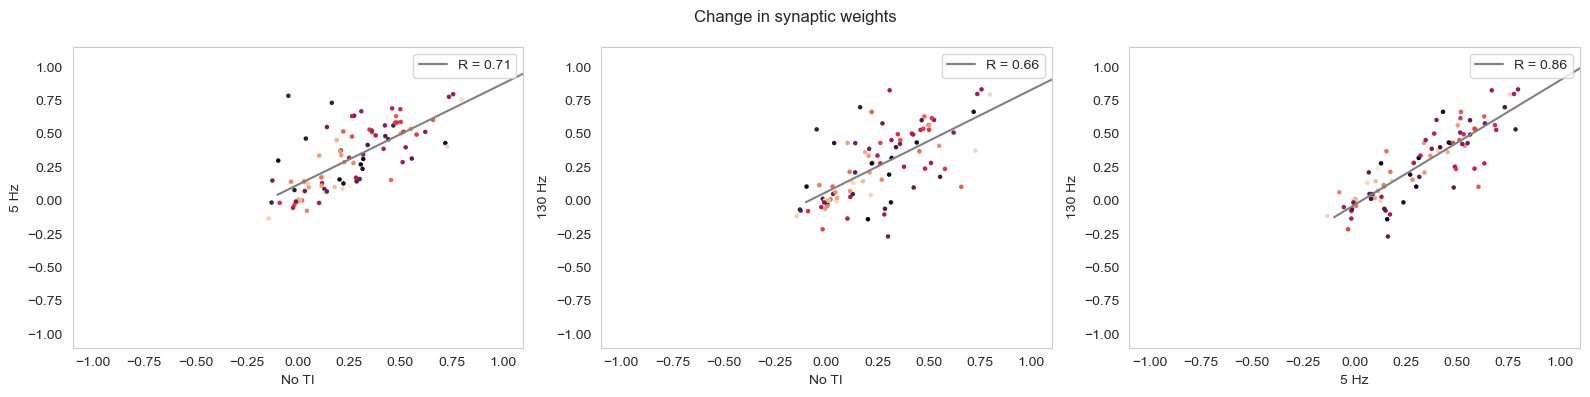

In [21]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (16, 4))

x = final_synaptic_weights["No TI"] - original_synaptic_weights["No TI"]
y = final_synaptic_weights["5 Hz"] - original_synaptic_weights["5 Hz"]

axs[0].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[0], locations = locations)

axs[0].set_xlabel("No TI")
axs[0].set_ylabel("5 Hz")
axs[0].set_xlim(-1.1, 1.1)
axs[0].set_ylim(-1.1, 1.15)
axs[0].legend(loc = "upper right")
axs[0].grid()

x = final_synaptic_weights["No TI"] - original_synaptic_weights["No TI"]
y = final_synaptic_weights["130 Hz"] - original_synaptic_weights["130 Hz"]

axs[1].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[1], locations = locations)

axs[1].set_xlabel("No TI")
axs[1].set_ylabel("130 Hz")
axs[1].set_xlim(-1.1, 1.1)
axs[1].set_ylim(-1.1, 1.15)
axs[1].legend(loc = "upper right")
axs[1].grid()

x = final_synaptic_weights["5 Hz"] - original_synaptic_weights["5 Hz"]
y = final_synaptic_weights["130 Hz"] - original_synaptic_weights["130 Hz"]

axs[2].scatter(
    x,
    y,
    s = 5,
    c = locations
)

plot_correlation_line(x, y, ax = axs[2], locations = locations)

axs[2].set_xlabel("5 Hz")
axs[2].set_ylabel("130 Hz")
axs[2].set_xlim(-1.1, 1.1)
axs[2].set_ylim(-1.1, 1.15)
axs[2].legend(loc = "upper right")
axs[2].grid()

fig.suptitle("Change in synaptic weights")
fig.tight_layout()

plt.show()

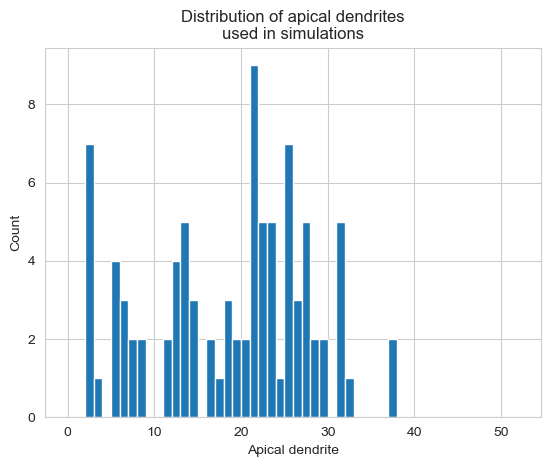

In [22]:
bin_edges = np.arange(0, 53)

plt.hist(
    dendrites,
    bins = bin_edges
)

plt.xlabel("Apical dendrite")
plt.ylabel("Count")
plt.title("Distribution of apical dendrites\nused in simulations")

plt.show()

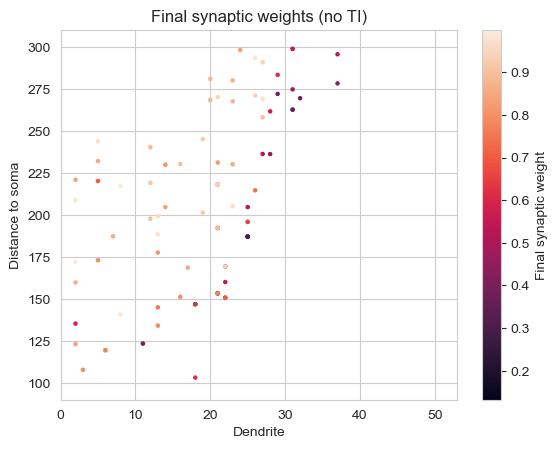

In [23]:
plt.scatter(
    dendrites,
    distances,
    s = 5,
    c = final_synaptic_weights["No TI"]
)

plt.ylim(90, 310)
plt.xlim(0, 53)

plt.ylabel("Distance to soma")
plt.xlabel("Dendrite")

plt.colorbar(label = "Final synaptic weight")

plt.title("Final synaptic weights (no TI)")

# Depends on the location along the dendrite. What should I do with this information?

plt.show()

### The final synaptic weight depends on the location along the dendrite

In [24]:
import seaborn as sns

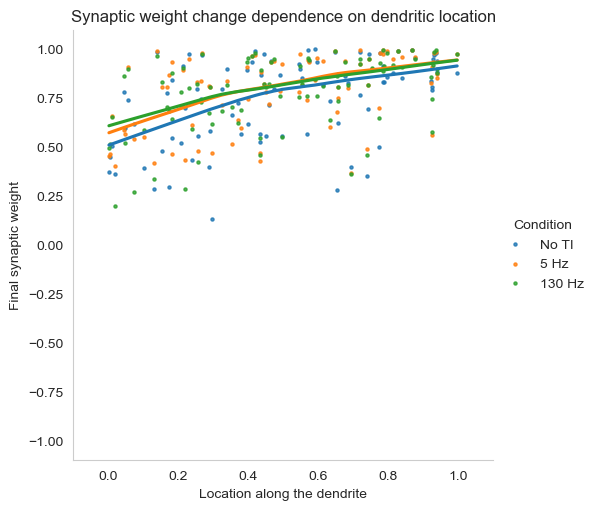

In [25]:
df = pd.concat([
    pd.DataFrame({
        "Location": locations,
        "Weight": final_synaptic_weights[type],
        "Condition": type
    })

    for type in original_synaptic_weights.keys()
])

# Estimates locally weighted linear regression
sns.lmplot(
    df,
    lowess = True,
    x = "Location", y = "Weight", hue = "Condition",
    scatter_kws = { "s": 5 }
)

plt.xlim(-0.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Location along the dendrite")
plt.ylabel("Final synaptic weight")

plt.grid()
plt.title("Synaptic weight change dependence on dendritic location")

plt.show()

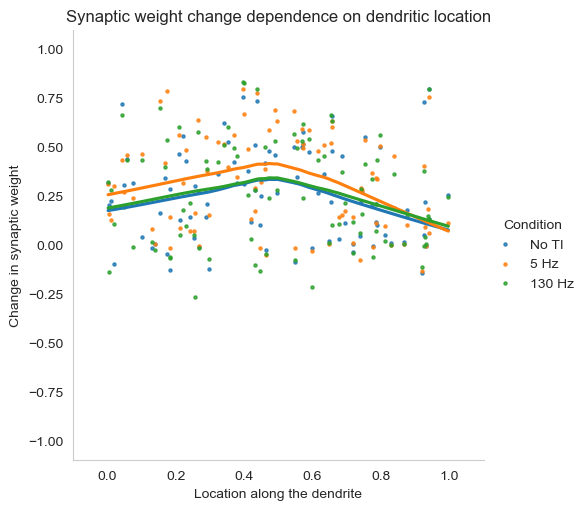

In [26]:
df = pd.concat([
    pd.DataFrame({
        "Location": locations,
        "Weight": final_synaptic_weights[type] - original_synaptic_weights[type],
        "Condition": type
    })

    for type in original_synaptic_weights.keys()
])

# Estimates locally weighted linear regression
sns.lmplot(
    df,
    lowess = True,
    x = "Location", y = "Weight", hue = "Condition",
    scatter_kws = { "s": 5 }
)

plt.xlim(-0.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Location along the dendrite")
plt.ylabel("Change in synaptic weight")

plt.grid()
plt.title("Synaptic weight change dependence on dendritic location")

plt.show()

Should I run more simulations

TODO: generate a plot of possible synaptic locations along all the dendrites and which ones are used in the simulations (might need to change the randomization to ensure equal coverage of all available locations).

In [27]:
# Split the data into multiple bins (proximal/mid/distal) to evaluate the significance

df["Region"] = pd.cut(df["Location"], bins = [0, 0.33, 0.66, 1], labels = ["Proximal", "Mid", "Distal"])

In [28]:
import pingouin as pg

In [29]:
dist_df = df[df["Region"] == "Distal"]

pg.pairwise_tests(
    dv = "Weight",
    between = "Condition",
    data = dist_df,
    padjust = "fdr_bh",
    parametric = False
)

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Condition,130 Hz,5 Hz,False,False,417.0,two-sided,0.962789,0.962789,fdr_bh,-0.027382
1,Condition,130 Hz,No TI,False,False,432.0,two-sided,0.864173,0.962789,fdr_bh,0.002816
2,Condition,5 Hz,No TI,False,False,434.0,two-sided,0.839786,0.962789,fdr_bh,0.028995


In [30]:
mid_df = df[df["Region"] == "Mid"]

pg.pairwise_tests(
    dv = "Weight",
    between = "Condition",
    data = mid_df,
    padjust = "fdr_bh",
    parametric = False
)

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Condition,130 Hz,5 Hz,False,False,432.0,two-sided,0.285765,0.428647,fdr_bh,-0.240767
1,Condition,130 Hz,No TI,False,False,534.0,two-sided,0.772823,0.772823,fdr_bh,-0.007723
2,Condition,5 Hz,No TI,False,False,638.0,two-sided,0.091968,0.275903,fdr_bh,0.271202


In [31]:
proximal_df = df[df["Region"] == "Proximal"]

pg.pairwise_tests(
    dv = "Weight",
    between = "Condition",
    data = proximal_df,
    padjust = "fdr_bh",
    parametric = False
)

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Condition,130 Hz,5 Hz,False,False,336.0,two-sided,0.191448,0.287171,fdr_bh,-0.339933
1,Condition,130 Hz,No TI,False,False,432.0,two-sided,0.864173,0.864173,fdr_bh,0.066405
2,Condition,5 Hz,No TI,False,False,521.0,two-sided,0.119915,0.287171,fdr_bh,0.455732


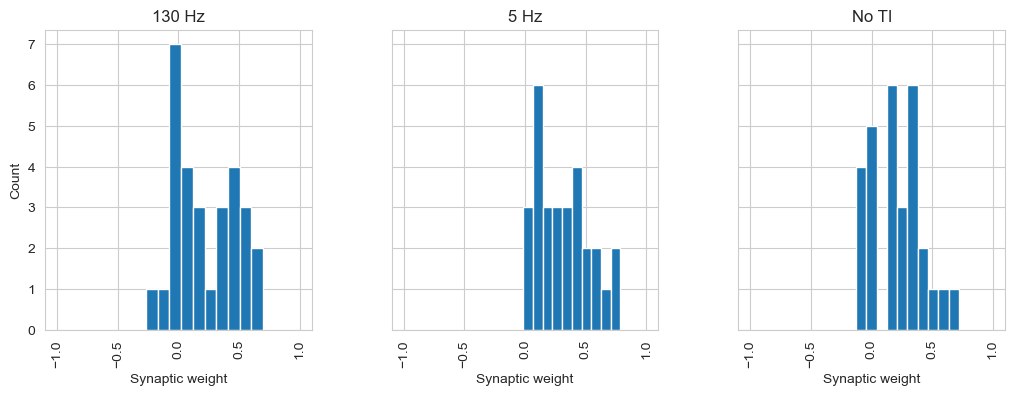

In [32]:
axs = proximal_df.hist(column = "Weight", by = "Condition", figsize = (12, 4), layout = (1, 3), sharey = True)

for ax in axs:
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel("Synaptic weight")
    ax.set_ylabel("Count")

plt.show()